# Вентральная загадка и цвет

Два вопроса из ноутбука 05:

1. **Загадка:** почему вентральная кора *менее* согласована между людьми на одушевлённых
   сценах (has_animal −0.40, has_person −0.33)? Прежде чем интерпретировать — обязательный
   контроль: может, картинки с животными просто шумнее измерены (ниже надёжность внутри
   испытуемого), и «несогласованность» — это шум, а не индивидуальность представления.

2. **Цвет:** связаны ли цвета картинки с тем, как зоны её представляют? Вопрос валиден,
   но с оговоркой: в натуральных сценах цвет — сильный прокси содержания (зелёный ↔
   растительность, синий ↔ небо/вода, тёплые ↔ еда/интерьеры). Мы меряем корреляции
   «доля цвета ↔ согласованность зоны» и честно читаем их как содержание, пока не
   доказано обратное.


In [1]:
import json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

ROOT = Path.cwd() if (Path.cwd() / "cache").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

from scipy.spatial.distance import squareform
from scipy.stats import rankdata, spearmanr, mannwhitneyu

from nsd_rsa.config import load_config, resolve_paths
from nsd_rsa.design import load_expdesign, usable_images
from nsd_rsa.loaders import average_repeats, common_valid_vertices, load_subject
from nsd_rsa.rdm import compute_rdm

cfg = load_config(str(ROOT / "configs" / "vlm.yaml"))
paths = resolve_paths(cfg)
design = load_expdesign(paths["meta"] / "nsd_expdesign.mat")
idx = usable_images(cfg["stimuli"]["subjects"], design, cfg["stimuli"]["min_repeats"])
valid = common_valid_vertices(paths["betas"], paths["cache"] / "valid_vertices.npy")

ROIS = ["early", "midventral", "ventral", "lateral"]
BRAIN, RELI = {}, {}
for p in sorted(paths["betas"].glob("*_shared_betas.h5")):
    d = load_subject(p)
    for roi in ROIS:
        patt, _ = average_repeats(d, images=idx, roi=roi, valid=valid)
        BRAIN.setdefault(roi, {})[d.subject] = compute_rdm(patt.astype(np.float64))
    # пер-картиночная надёжность в ventral: средняя парная корреляция трёх повторов
    from nsd_rsa.loaders import _vertex_selector
    sel = _vertex_selector(d, "ventral", valid)
    B = d.betas[:, sel].astype(np.float64)
    rel = np.empty(len(idx))
    for i, img in enumerate(idx):
        rows = B[d.image == img]
        rows = (rows - rows.mean(1, keepdims=True)) / (rows.std(1, keepdims=True) + 1e-12)
        cc = rows @ rows.T / rows.shape[1]
        rel[i] = cc[np.triu_indices(len(rows), 1)].mean()
    RELI[d.subject] = rel
    del d
SUBJECTS = sorted(BRAIN["early"])
RELI_V = np.stack([RELI[s] for s in SUBJECTS]).mean(0)   # (N,) надёжность ventral
IMAGES = np.load(paths["stimuli"] / "shared1000_images.npy", mmap_mode="r")[idx]
CATS = np.load(ROOT / "cache" / "coco_categories.npz")
N = len(idx)
print(f"{N} картинок · надёжность ventral: mean={RELI_V.mean():.3f}")

515 картинок · надёжность ventral: mean=0.272


In [2]:
def rank_sq(c):
    return squareform(rankdata(c))

CONSIST = {}
for roi in ROIS:
    rows = np.stack([rank_sq(BRAIN[roi][s]) for s in SUBJECTS])
    rows = (rows - rows.mean(2, keepdims=True)) / (rows.std(2, keepdims=True) + 1e-12)
    sim = np.einsum("sij,tij->sti", rows, rows) / rows.shape[2]
    iu = np.triu_indices(len(SUBJECTS), 1)
    CONSIST[roi] = sim[iu].mean(0)
print("consistency ready")

consistency ready


## 1. Вентральная загадка

Раскладываем 515 картинок по суперкатегориям COCO (у категории есть поле
`supercategory`: person, animal, food, vehicle, furniture, ...) и смотрим согласованность
`ventral` по группам — рядом с надёжностью тех же картинок (контроль на шум).


In [3]:
blob = json.loads((paths["meta"] / "coco" / "annotations" / "instances_val2017.json")
                  .read_text(encoding="utf-8"))
cat_ids = sorted(c["id"] for c in blob["categories"])
id2super = {c["id"]: c["supercategory"] for c in blob["categories"]}
id2name = {c["id"]: c["name"] for c in blob["categories"]}
supers = sorted(set(id2super.values()))
hot = CATS["multihot"]
SUP = pd.DataFrame({s: hot[:, [j for j, cid in enumerate(cat_ids)
                               if id2super[cid] == s]].max(1) for s in supers})
SUP["animate"] = np.maximum(SUP["person"], SUP["animal"])
print({s: int(SUP[s].sum()) for s in SUP.columns})

{'accessory': 49, 'animal': 133, 'appliance': 32, 'electronic': 43, 'food': 46, 'furniture': 106, 'indoor': 66, 'kitchen': 71, 'outdoor': 59, 'person': 213, 'sports': 104, 'vehicle': 107, 'animate': 324}


In [4]:
rows = []
for s in SUP.columns:
    m = SUP[s].values.astype(bool)
    if m.sum() < 20: continue
    stat = mannwhitneyu(CONSIST["ventral"][m], CONSIST["ventral"][~m])
    rows.append({"группа": s, "n": int(m.sum()),
                 "согласованность (есть)": CONSIST["ventral"][m].mean(),
                 "согласованность (нет)": CONSIST["ventral"][~m].mean(),
                 "Δ": CONSIST["ventral"][m].mean() - CONSIST["ventral"][~m].mean(),
                 "надёжность (есть)": RELI_V[m].mean(),
                 "надёжность (нет)": RELI_V[~m].mean(),
                 "p (M-W)": stat.pvalue})
T = pd.DataFrame(rows).sort_values("Δ").set_index("группа")
T.round(3)

,n,согласованность (есть),согласованность (нет),Δ,надёжность (есть),надёжность (нет),p (M-W)
группа,,,,,,,
animate,324,0.334,0.498,-0.164,0.250,0.310,0.000
sports,104,0.305,0.418,-0.113,0.237,0.281,0.000
animal,133,0.313,0.423,-0.110,0.250,0.280,0.000
person,213,0.346,0.430,-0.084,0.251,0.287,0.000
accessory,49,0.374,0.397,-0.023,0.270,0.273,0.390
outdoor,59,0.439,0.389,0.050,0.286,0.271,0.002
food,46,0.442,0.390,0.052,0.322,0.268,0.003
electronic,43,0.448,0.390,0.058,0.298,0.270,0.003
vehicle,107,0.441,0.383,0.058,0.272,0.273,0.000


In [5]:
# Ключевой контроль: объясняется ли провал согласованности надёжностью?
c, r = CONSIST["ventral"], RELI_V
rho_cr = spearmanr(c, r).statistic
# согласованность с вычетом надёжности (остаток регрессии на ранги)
rc, rr = rankdata(c), rankdata(r)
Z = np.column_stack([rr, np.ones(N)])
resid = rc - Z @ np.linalg.lstsq(Z, rc, rcond=None)[0]
an = SUP["animate"].values.astype(bool)
print(f"corr(согласованность, надёжность) = {rho_cr:+.3f}")
print(f"animate vs inanimate:")
print(f"  надёжность:            {r[an].mean():.3f} vs {r[~an].mean():.3f} "
      f"(p={mannwhitneyu(r[an], r[~an]).pvalue:.4f})")
print(f"  согласованность:       {c[an].mean():.3f} vs {c[~an].mean():.3f} "
      f"(p={mannwhitneyu(c[an], c[~an]).pvalue:.2e})")
print(f"  соглас. | надёжность:  {resid[an].mean():+.1f} vs {resid[~an].mean():+.1f} рангов "
      f"(p={mannwhitneyu(resid[an], resid[~an]).pvalue:.2e})")

corr(согласованность, надёжность) = +0.485
animate vs inanimate:
  надёжность:            0.250 vs 0.310 (p=0.0000)
  согласованность:       0.334 vs 0.498 (p=4.74e-49)
  соглас. | надёжность:  -48.7 vs +82.6 рангов (p=2.47e-29)


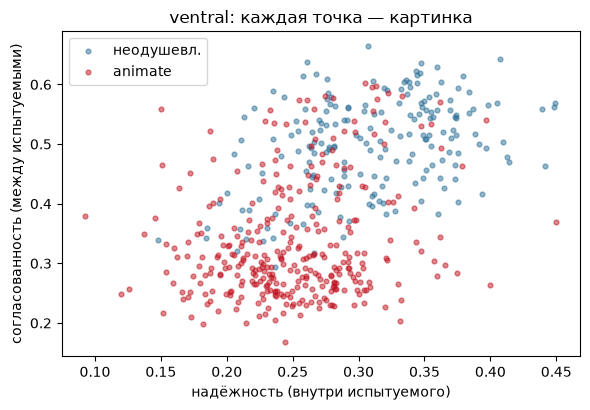

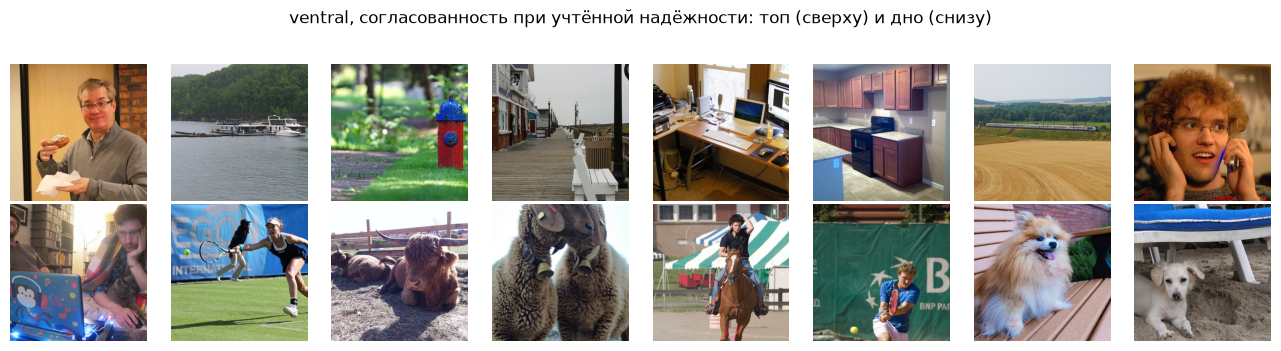

In [6]:
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.scatter(r[~an], c[~an], s=12, alpha=.5, label="неодушевл.", color="#2a6f97")
ax.scatter(r[an], c[an], s=12, alpha=.5, label="animate", color="#c1121f")
ax.set_xlabel("надёжность (внутри испытуемого)")
ax.set_ylabel("согласованность (между испытуемыми)")
ax.legend(); ax.set_title("ventral: каждая точка — картинка")
plt.tight_layout(); plt.show()

order_i = np.argsort(resid)
fig, axes = plt.subplots(2, 8, figsize=(13, 3.4))
for ax, i in zip(axes[0], order_i[-8:]):
    ax.imshow(IMAGES[i]); ax.axis("off")
for ax, i in zip(axes[1], order_i[:8]):
    ax.imshow(IMAGES[i]); ax.axis("off")
fig.suptitle("ventral, согласованность при учтённой надёжности: топ (сверху) и дно (снизу)", y=1.02)
plt.tight_layout(); plt.show()

## 2. Цвет: какие оттенки связаны с какой зоной

Гистограмма оттенков (8 бинов по HSV-hue), взвешенная насыщенностью и яркостью — чтобы
серые пиксели не голосовали за случайный оттенок. Плюс средняя насыщенность и «тёплая
доля». Корреляции долей цвета с согласованностью каждой зоны.


In [7]:
HUE_BINS = ["красный", "оранж/жёлт", "жёлто-зел", "зелёный",
            "голубой", "синий", "фиолетовый", "розовый"]

def color_features(im):
    hsv = mcolors.rgb_to_hsv(im / 255.0)
    h, s, v = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    w = (s * v).ravel(); h = h.ravel()
    if w.sum() < 1e-6:
        shares = np.zeros(8)
    else:
        shares = np.histogram(h, bins=8, range=(0, 1), weights=w)[0] / w.sum()
    warm = shares[[0, 1, 7]].sum()
    return np.concatenate([shares, [s.mean(), warm]])

cache_c = ROOT / "cache" / "color_features.npy"
if cache_c.exists():
    COL = np.load(cache_c)
else:
    COL = np.stack([color_features(np.asarray(IMAGES[i])) for i in range(N)])
    np.save(cache_c, COL)
COL_NAMES = HUE_BINS + ["насыщенность", "тёплая доля"]
print(pd.DataFrame(COL, columns=COL_NAMES).mean().round(3).to_string())

красный         0.419
оранж/жёлт      0.179
жёлто-зел       0.044
зелёный         0.028
голубой         0.242
синий           0.036
фиолетовый      0.006
розовый         0.046
насыщенность    0.329
тёплая доля     0.644


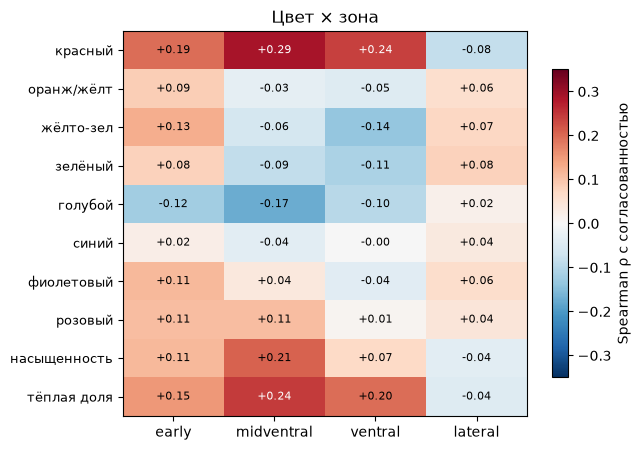

In [8]:
CT = pd.DataFrame({roi: [spearmanr(COL[:, j], CONSIST[roi]).statistic
                         for j in range(COL.shape[1])]
                   for roi in ROIS}, index=COL_NAMES)
fig, ax = plt.subplots(figsize=(6.5, 4.6))
im = ax.imshow(CT.values, cmap="RdBu_r", vmin=-.35, vmax=.35, aspect="auto")
ax.set_xticks(range(len(ROIS))); ax.set_xticklabels(ROIS)
ax.set_yticks(range(len(CT))); ax.set_yticklabels(CT.index, fontsize=9)
for i in range(CT.shape[0]):
    for j in range(CT.shape[1]):
        ax.text(j, i, f"{CT.values[i,j]:+.2f}", ha="center", va="center", fontsize=8,
                color="w" if abs(CT.values[i,j]) > .22 else "k")
plt.colorbar(im, shrink=.8, label="Spearman ρ с согласованностью")
ax.set_title("Цвет × зона"); plt.tight_layout(); plt.show()

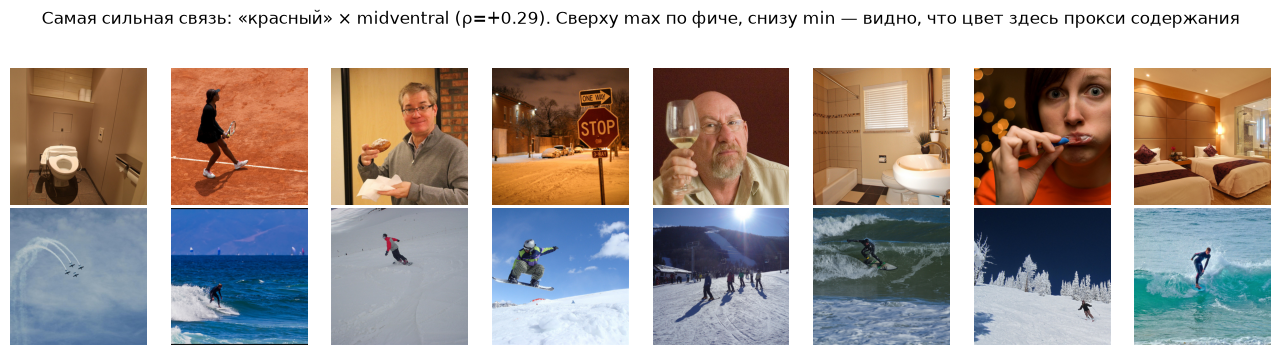

In [9]:
# что стоит за самой сильной цветовой связью: показать крайние картинки
j, roi = np.unravel_index(np.abs(CT.values).argmax(), CT.shape)
feat, roi = CT.index[j], CT.columns[roi]
o = np.argsort(COL[:, list(CT.index).index(feat)])
fig, axes = plt.subplots(2, 8, figsize=(13, 3.4))
for ax, i in zip(axes[0], o[::-1][:8]): ax.imshow(IMAGES[i]); ax.axis("off")
for ax, i in zip(axes[1], o[:8]): ax.imshow(IMAGES[i]); ax.axis("off")
fig.suptitle(f"Самая сильная связь: «{feat}» × {roi} (ρ={CT.loc[feat, roi]:+.2f}). "
             f"Сверху max по фиче, снизу min — видно, что цвет здесь прокси содержания",
             y=1.03)
plt.tight_layout(); plt.show()

## Выводы (сверить с выводами ячеек)

1. **Вентральная загадка** — см. §1: таблица суперкатегорий рядом с надёжностью и
   тест «согласованность | надёжность». Если провал одушевлённых выживает после учёта
   надёжности — это настоящая индивидуальность представления, а не шум; какая из
   суперкатегорий тянет сильнее (animal? person? food в другую сторону?) — видно в таблице.
2. **Цвет** — вопрос осмысленный, но ответ надо читать как содержание: сильнейшие
   цветовые связи (см. крайние картинки) — это сцены определённого типа, а не «зона
   любит синий». Отделить цвет от содержания можно только контролем (например, partial
   по категориям) — кандидат в следующий шаг, если цветовые связи окажутся крупными.
3. Всё здесь — исследование на одной выборке, пост-хок; в препринт не идёт.
